In [1]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)
library(limma)
theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

Warning message:
“package ‘DESeq2’ was built under R version 4.2.3”
Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.2.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.2.1”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    exp

In [13]:
final_iso_tb<- read.table("../data/2_final_iso_tb.tsv", sep = "\t", header = T)
length(unique(final_iso_tb$gene_id))
dim(final_iso_tb)[1]

# final number of annotated isoforms: 6292
# final number of annotated genes: 6016

# remove intron-containing genes
intron_genes<- final_iso_tb  %>% filter(blockCount > 1) %>% pull(gene_id) %>% sort() %>% unique()
final_iso_tb<- final_iso_tb %>% filter(!gene_id %in% intron_genes)
length(unique(final_iso_tb$gene_id))
dim(final_iso_tb)[1]

# final number of annotated isoforms: 5741
# final number of annotated genes: 5741

[1] 6016

[1] 6292

[1] 5741

[1] 5741

In [132]:
tpm_mature<- read.table("../data/7_mature_rna_tss_tpm.tsv", sep = "\t", check.names = F)
tpm_nascent<- read.table('../data/7_nascent_rna_tss_tpm.tsv', header = T, row.names = 1, sep = '\t', check.names = F)

colnames(tpm_mature)<- paste0("Mature-", rep(c("WT", "MUT"), each = 3), '-', rep(c("rep1", "rep2", "rep3"), 2))
colnames(tpm_nascent)<- paste0("Nascent-", rep(c("WT", "MUT"), each = 2), '-', rep(c("rep1", "rep2"), 2))
head(tpm_mature, 3)
head(tpm_nascent, 3)

all_iso<- c(rownames(tpm_mature), rownames(tpm_nascent)) %>% sort() %>% unique()

tpm_mature <- tpm_mature[all_iso, , drop = FALSE]
tpm_nascent <- tpm_nascent[all_iso, , drop = FALSE]

tpm<- cbind(tpm_mature, tpm_nascent)

rownames(tpm) = all_iso
tpm[is.na(tpm)] <- 0
tpm =tpm[!rowSums(tpm) == 0, ]
tpm<- log2(tpm+1)

,Mature-WT-rep1,Mature-WT-rep2,Mature-WT-rep3,Mature-MUT-rep1,Mature-MUT-rep2,Mature-MUT-rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAC1:atss_AAC1,0.000000,0.000000,0.000000,0.000000,0.19256,0.000000
AAC1:citss_AAC1,6.535484,2.266684,5.782025,5.950649,4.81400,3.649682
AAC1:tss_AAC1,4.356989,3.400027,3.469215,4.384689,3.08096,2.554777


,Nascent-WT-rep1,Nascent-WT-rep2,Nascent-MUT-rep1,Nascent-MUT-rep2
,<dbl>,<dbl>,<dbl>,<dbl>
AAC1:atss_AAC1,0.6997577,1.668969,1.210898,1.875965
AAC1:citss_AAC1,9.0968507,6.258634,7.265387,5.627895
AAC1:tss_AAC1,4.1985465,7.927603,6.054489,1.250643


In [133]:
# filter to short genes
final_iso_tb<- final_iso_tb %>% filter(isolen < 2000)

wt_tpm <- tpm %>% 
            mutate(
                mature_WT_avg = rowMeans(select(., starts_with("Mature-WT"))),
                nascent_WT_avg = rowMeans(select(., starts_with("Nascent-WT")))) %>%
            select(mature_WT_avg, nascent_WT_avg) %>% 
        mutate(gene_id = str_split_i(rownames(tpm), "_", 2)) %>%
        mutate(iso_id = str_split_i(rownames(tpm), "_", 1)) %>% 
        filter(gene_id %in% final_iso_tb$gene_id)
wt_tpm <- wt_tpm %>% mutate(feature_id = str_split_i(iso_id, ":", 2))


mut_tpm <- tpm %>% 
            mutate(
                mature_MUT_avg = rowMeans(select(., starts_with("Mature-MUT"))),
                nascent_MUT_avg = rowMeans(select(., starts_with("Nascent-MUT")))) %>%
            select(mature_MUT_avg, nascent_MUT_avg) %>% 
        mutate(gene_id = str_split_i(rownames(tpm), "_", 2)) %>%
        mutate(iso_id = str_split_i(rownames(tpm), "_", 1)) %>% 
        filter(gene_id %in% final_iso_tb$gene_id)
mut_tpm <- mut_tpm %>% mutate(feature_id = str_split_i(iso_id, ":", 2))


In [86]:
mcolors <- c("#B25D91FF", "#5E8C61FF", "#FFC857FF")
mcolors<- c(mcolors, "grey")
names(mcolors) <- c('tss', 'citss', 'atss', 'Not sig')

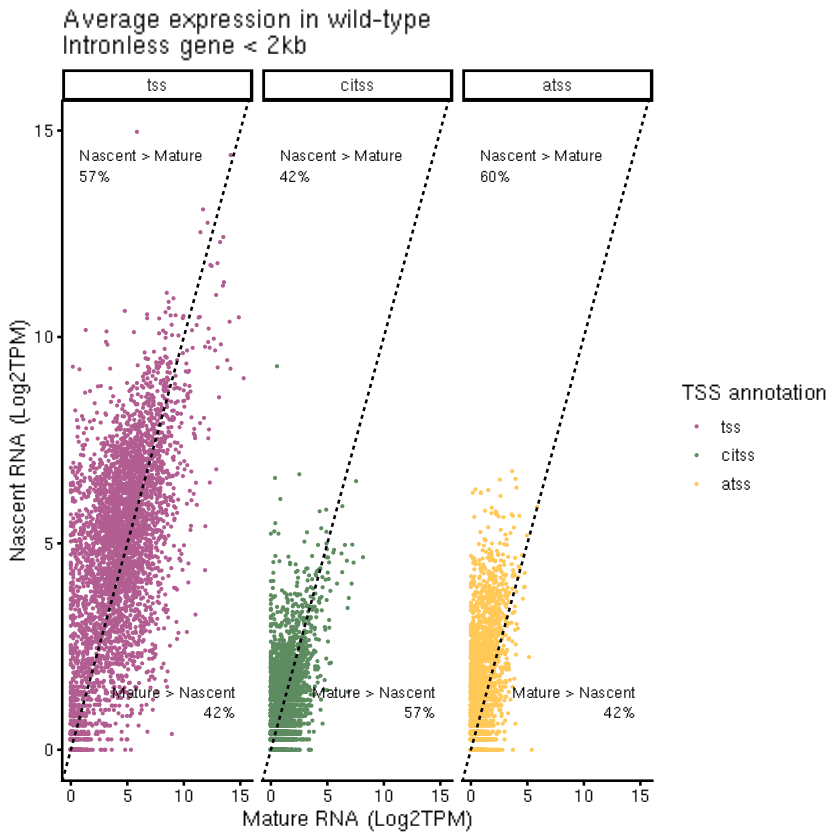

In [134]:
fractions <- wt_tpm %>%
    mutate(feature_id = factor(feature_id, levels = c("tss", "citss", "atss")),
           above_line = nascent_WT_avg > mature_WT_avg) %>%
    group_by(feature_id) %>%
    summarise(
        frac_above = mean(above_line, na.rm = TRUE),
        frac_below = 1 - mean(above_line, na.rm = TRUE),
        .groups = "drop"
    ) %>%
    mutate(
        label_above = paste0("Nascent > Mature\n", scales::percent(frac_above, accuracy = 3)),
        label_below = paste0("Mature > Nascent\n", scales::percent(frac_below, accuracy = 3))
    )
axis_min <- min(c(wt_tpm$mature_WT_avg, wt_tpm$nascent_WT_avg), na.rm = TRUE)
axis_max <- max(c(wt_tpm$mature_WT_avg, wt_tpm$nascent_WT_avg), na.rm = TRUE)



wt_tpm %>%
    mutate(feature_id = factor(feature_id, levels = c("tss", "citss", "atss"))) %>% 
    ggplot(aes(x = mature_WT_avg, y = nascent_WT_avg)) +
    geom_point(aes(, color = feature_id), size = 0.05, alpha = 1) +
    # stat_cor(method = "pearson") +
    labs(x = "Mature RNA (Log2TPM)", y = "Nascent RNA (Log2TPM)", 
         title = "Average expression in wild-type\nIntronless gene < 2kb",
        color = "TSS annotation") +
    geom_text(data = fractions,
              aes(x = axis_min + (axis_max - axis_min) * 0.05,
                  y = axis_max - (axis_max - axis_min) * 0.05,
                  label = label_above),
              hjust = 0, vjust = 1, size = 3, color = "black") +
    geom_text(data = fractions,
              aes(x = axis_max - (axis_max - axis_min) * 0.05,
                  y = axis_min + (axis_max - axis_min) * 0.05,
                  label = label_below),
              hjust = 1, vjust = 0, size = 3, color = "black") +
    scale_color_manual(values = mcolors) +
    geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "black") +
    facet_wrap(~feature_id, ncol = 3)

ggsave("../figures/7_nascent_mature_rna_isoform_expr_correlation_WT.pdf", width = 6, height = 3)

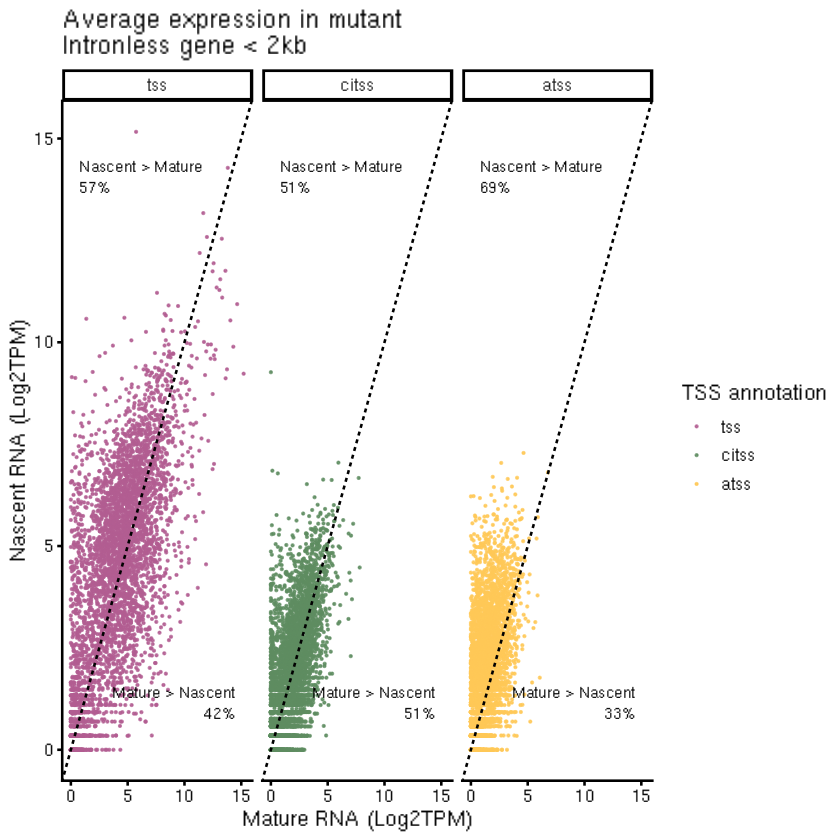

In [135]:
# top_var_genes = mut_tpm %>% mutate(delta = mature_MUT_avg - nascent_MUT_avg) %>% arrange(delta)
# up_genes = top_var_genes %>% head(10)
# down_genes = top_var_genes %>% tail(10)

fractions <- mut_tpm %>%
    mutate(feature_id = factor(feature_id, levels = c("tss", "citss", "atss")),
           above_line = nascent_MUT_avg > mature_MUT_avg) %>%
    group_by(feature_id) %>%
    summarise(
        frac_above = mean(above_line, na.rm = TRUE),
        frac_below = 1 - mean(above_line, na.rm = TRUE),
        .groups = "drop"
    ) %>%
    mutate(
        label_above = paste0("Nascent > Mature\n", scales::percent(frac_above, accuracy = 3)),
        label_below = paste0("Mature > Nascent\n", scales::percent(frac_below, accuracy = 3))
    )
axis_min <- min(c(mut_tpm$mature_MUT_avg, mut_tpm$nascent_MUT_avg), na.rm = TRUE)
axis_max <- max(c(mut_tpm$mature_MUT_avg, mut_tpm$nascent_MUT_avg), na.rm = TRUE)



mut_tpm %>%
    mutate(feature_id = factor(feature_id, levels = c("tss", "citss", "atss"))) %>% 
    ggplot(aes(x = mature_MUT_avg, y = nascent_MUT_avg)) +
    geom_point(aes(color = feature_id), size = 0.05, alpha = 0.8) +
    # stat_cor(method = "pearson") +
    labs(x = "Mature RNA (Log2TPM)", y = "Nascent RNA (Log2TPM)", 
         title = "Average expression in mutant\nIntronless gene < 2kb",
        color = "TSS annotation") +
    geom_text(data = fractions,
              aes(x = axis_min + (axis_max - axis_min) * 0.05,
                  y = axis_max - (axis_max - axis_min) * 0.05,
                  label = label_above),
              hjust = 0, vjust = 1, size = 3, color = "black") +
    geom_text(data = fractions,
              aes(x = axis_max - (axis_max - axis_min) * 0.05,
                  y = axis_min + (axis_max - axis_min) * 0.05,
                  label = label_below),
              hjust = 1, vjust = 0, size = 3, color = "black") +
    scale_color_manual(values = mcolors) +
    geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "black") +
    facet_wrap(~feature_id, ncol = 3)

ggsave("../figures/7_nascent_mature_rna_isoform_expr_correlation_MUT.pdf", width = 6, height = 3)

In [128]:
# tpm_mature<- read.table("../data/7_mature_rna_tss_tpm.tsv", sep = "\t", check.names = F)
# tpm_nascent<- read.table('../data/7_nascent_rna_tss_tpm.tsv', header = T, row.names = 1, sep = '\t', check.names = F)

# colnames(tpm_mature)<- paste0("Mature-", rep(c("WT", "MUT"), each = 3), '-', rep(c("rep1", "rep2", "rep3"), 2))
# colnames(tpm_nascent)<- paste0("Nascent-", rep(c("WT", "MUT"), each = 2), '-', rep(c("rep1", "rep2"), 2))
# head(tpm_mature, 3)
# head(tpm_nascent, 3)

# all_iso<- intersect(rownames(tpm_mature), rownames(tpm_nascent)) %>% sort() %>% unique()

# tpm_mature <- tpm_mature[all_iso, , drop = FALSE]
# tpm_nascent <- tpm_nascent[all_iso, , drop = FALSE]

# tpm<- cbind(tpm_mature, tpm_nascent)

# rownames(tpm) = all_iso
# tpm[is.na(tpm)] <- 0
# tpm =tpm[!rowSums(tpm) == 0, ]
# tpm<- log2(tpm+1)


# # filter to short genes
# final_iso_tb<- final_iso_tb %>% filter(isolen < 2000)

# wt_tpm <- tpm %>% 
#             mutate(
#                 mature_WT_avg = rowMeans(select(., starts_with("Mature-WT"))),
#                 nascent_WT_avg = rowMeans(select(., starts_with("Nascent-WT")))) %>%
#             select(mature_WT_avg, nascent_WT_avg) %>% 
#         mutate(gene_id = str_split_i(rownames(tpm), "_", 2)) %>%
#         mutate(iso_id = str_split_i(rownames(tpm), "_", 1)) %>% 
#         filter(gene_id %in% final_iso_tb$gene_id)
# wt_tpm <- wt_tpm %>% mutate(feature_id = str_split_i(iso_id, ":", 2))


# mut_tpm <- tpm %>% 
#             mutate(
#                 mature_MUT_avg = rowMeans(select(., starts_with("Mature-MUT"))),
#                 nascent_MUT_avg = rowMeans(select(., starts_with("Nascent-MUT")))) %>%
#             select(mature_MUT_avg, nascent_MUT_avg) %>% 
#         mutate(gene_id = str_split_i(rownames(tpm), "_", 2)) %>%
#         mutate(iso_id = str_split_i(rownames(tpm), "_", 1)) %>% 
#         filter(gene_id %in% final_iso_tb$gene_id)
# mut_tpm <- mut_tpm %>% mutate(feature_id = str_split_i(iso_id, ":", 2))


,Mature-WT-rep1,Mature-WT-rep2,Mature-WT-rep3,Mature-MUT-rep1,Mature-MUT-rep2,Mature-MUT-rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAC1:atss_AAC1,0.000000,0.000000,0.000000,0.000000,0.19256,0.000000
AAC1:citss_AAC1,6.535484,2.266684,5.782025,5.950649,4.81400,3.649682
AAC1:tss_AAC1,4.356989,3.400027,3.469215,4.384689,3.08096,2.554777


,Nascent-WT-rep1,Nascent-WT-rep2,Nascent-MUT-rep1,Nascent-MUT-rep2
,<dbl>,<dbl>,<dbl>,<dbl>
AAC1:atss_AAC1,0.6997577,1.668969,1.210898,1.875965
AAC1:citss_AAC1,9.0968507,6.258634,7.265387,5.627895
AAC1:tss_AAC1,4.1985465,7.927603,6.054489,1.250643


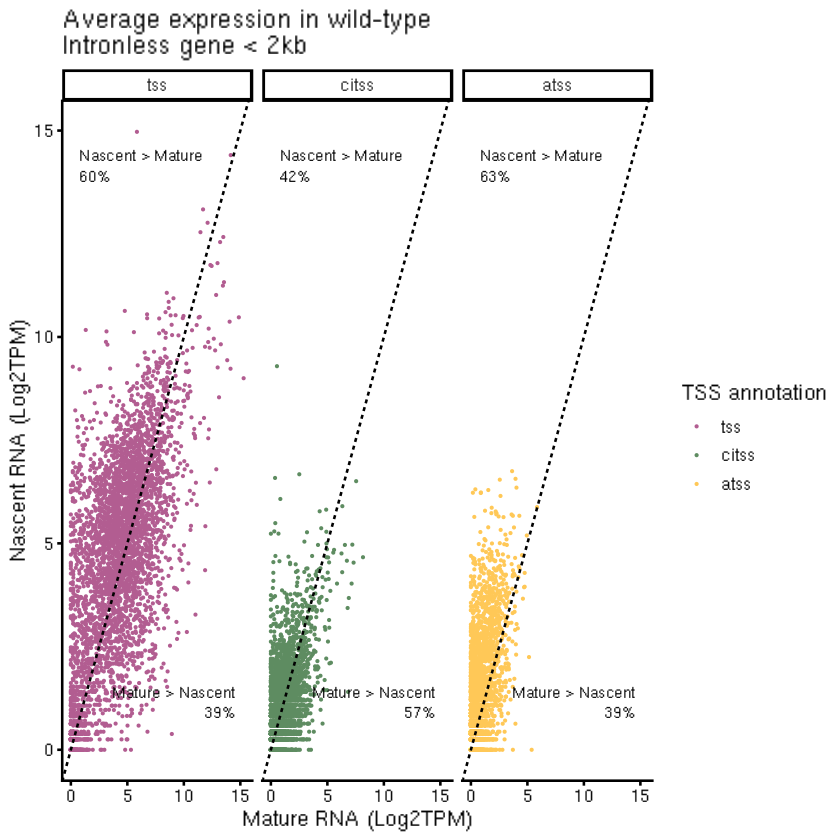

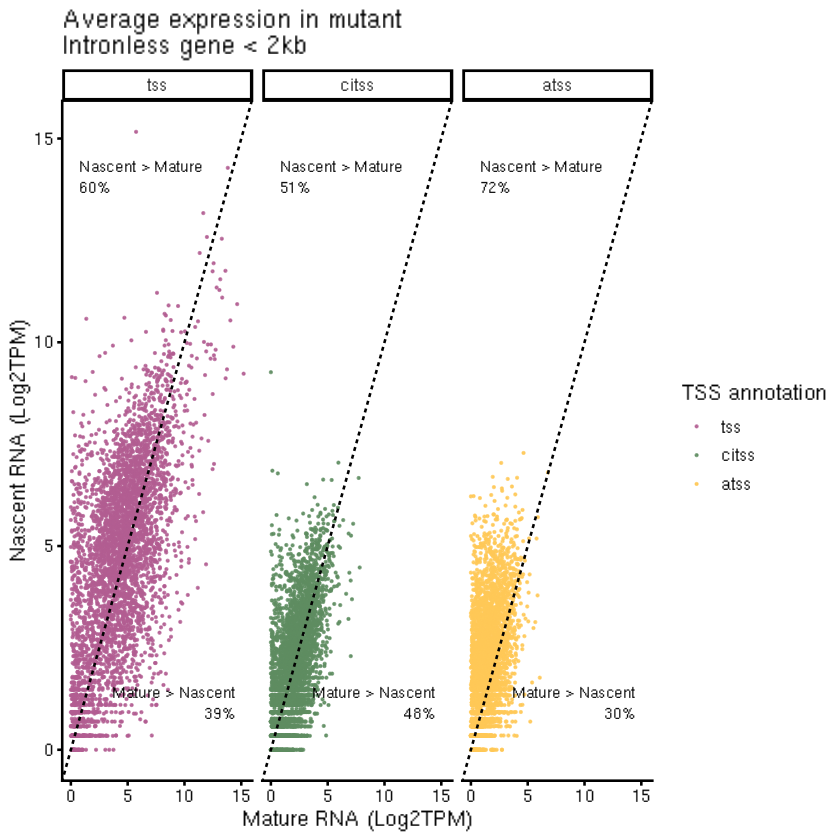

In [130]:
# fractions <- wt_tpm %>%
#     mutate(feature_id = factor(feature_id, levels = c("tss", "citss", "atss")),
#            above_line = nascent_WT_avg > mature_WT_avg) %>%
#     group_by(feature_id) %>%
#     summarise(
#         frac_above = mean(above_line, na.rm = TRUE),
#         frac_below = 1 - mean(above_line, na.rm = TRUE),
#         .groups = "drop"
#     ) %>%
#     mutate(
#         label_above = paste0("Nascent > Mature\n", scales::percent(frac_above, accuracy = 3)),
#         label_below = paste0("Mature > Nascent\n", scales::percent(frac_below, accuracy = 3))
#     )
# axis_min <- min(c(wt_tpm$mature_WT_avg, wt_tpm$nascent_WT_avg), na.rm = TRUE)
# axis_max <- max(c(wt_tpm$mature_WT_avg, wt_tpm$nascent_WT_avg), na.rm = TRUE)



# wt_tpm %>%
#     mutate(feature_id = factor(feature_id, levels = c("tss", "citss", "atss"))) %>% 
#     ggplot(aes(x = mature_WT_avg, y = nascent_WT_avg)) +
#     geom_point(aes(, color = feature_id), size = 0.05, alpha = 1) +
#     # stat_cor(method = "pearson") +
#     labs(x = "Mature RNA (Log2TPM)", y = "Nascent RNA (Log2TPM)", 
#          title = "Average expression in wild-type\nIntronless gene < 2kb",
#         color = "TSS annotation") +
#     geom_text(data = fractions,
#               aes(x = axis_min + (axis_max - axis_min) * 0.05,
#                   y = axis_max - (axis_max - axis_min) * 0.05,
#                   label = label_above),
#               hjust = 0, vjust = 1, size = 3, color = "black") +
#     geom_text(data = fractions,
#               aes(x = axis_max - (axis_max - axis_min) * 0.05,
#                   y = axis_min + (axis_max - axis_min) * 0.05,
#                   label = label_below),
#               hjust = 1, vjust = 0, size = 3, color = "black") +
#     scale_color_manual(values = mcolors) +
#     geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "black") +
#     facet_wrap(~feature_id, ncol = 3)

# ggsave("../figures/7_nascent_mature_rna_isoform_expr_correlation_WT.pdf", width = 6, height = 3)

# # top_var_genes = mut_tpm %>% mutate(delta = mature_MUT_avg - nascent_MUT_avg) %>% arrange(delta)
# # up_genes = top_var_genes %>% head(10)
# # down_genes = top_var_genes %>% tail(10)

# fractions <- mut_tpm %>%
#     mutate(feature_id = factor(feature_id, levels = c("tss", "citss", "atss")),
#            above_line = nascent_MUT_avg > mature_MUT_avg) %>%
#     group_by(feature_id) %>%
#     summarise(
#         frac_above = mean(above_line, na.rm = TRUE),
#         frac_below = 1 - mean(above_line, na.rm = TRUE),
#         .groups = "drop"
#     ) %>%
#     mutate(
#         label_above = paste0("Nascent > Mature\n", scales::percent(frac_above, accuracy = 3)),
#         label_below = paste0("Mature > Nascent\n", scales::percent(frac_below, accuracy = 3))
#     )
# axis_min <- min(c(mut_tpm$mature_MUT_avg, mut_tpm$nascent_MUT_avg), na.rm = TRUE)
# axis_max <- max(c(mut_tpm$mature_MUT_avg, mut_tpm$nascent_MUT_avg), na.rm = TRUE)



# mut_tpm %>%
#     mutate(feature_id = factor(feature_id, levels = c("tss", "citss", "atss"))) %>% 
#     ggplot(aes(x = mature_MUT_avg, y = nascent_MUT_avg)) +
#     geom_point(aes(color = feature_id), size = 0.05, alpha = 0.8) +
#     # stat_cor(method = "pearson") +
#     labs(x = "Mature RNA (Log2TPM)", y = "Nascent RNA (Log2TPM)", 
#          title = "Average expression in mutant\nIntronless gene < 2kb",
#         color = "TSS annotation") +
#     geom_text(data = fractions,
#               aes(x = axis_min + (axis_max - axis_min) * 0.05,
#                   y = axis_max - (axis_max - axis_min) * 0.05,
#                   label = label_above),
#               hjust = 0, vjust = 1, size = 3, color = "black") +
#     geom_text(data = fractions,
#               aes(x = axis_max - (axis_max - axis_min) * 0.05,
#                   y = axis_min + (axis_max - axis_min) * 0.05,
#                   label = label_below),
#               hjust = 1, vjust = 0, size = 3, color = "black") +
#     scale_color_manual(values = mcolors) +
#     geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "black") +
#     facet_wrap(~feature_id, ncol = 3)

# ggsave("../figures/7_nascent_mature_rna_isoform_expr_correlation_MUT.pdf", width = 6, height = 3)